MC scale:      3.2896e-02
Offbeam scale: 9.5295e-02


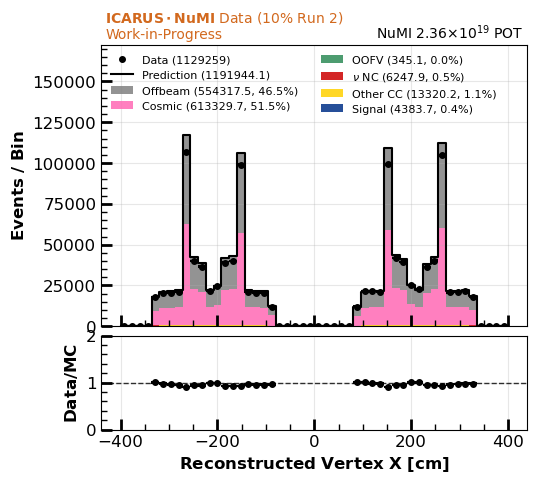

Saved: preselection_vertex_x


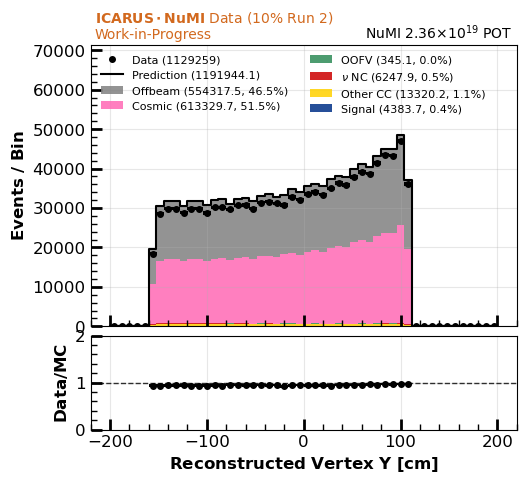

Saved: preselection_vertex_y


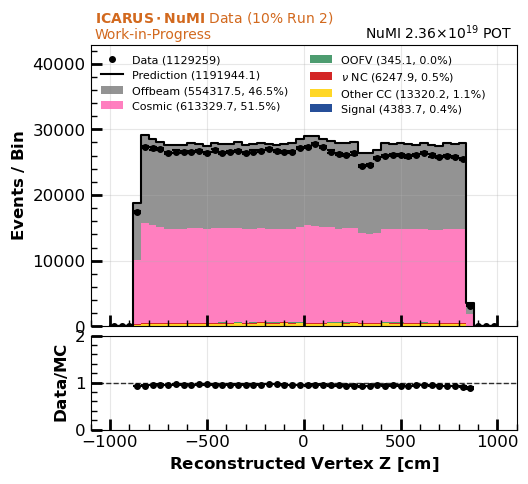

Saved: preselection_vertex_z


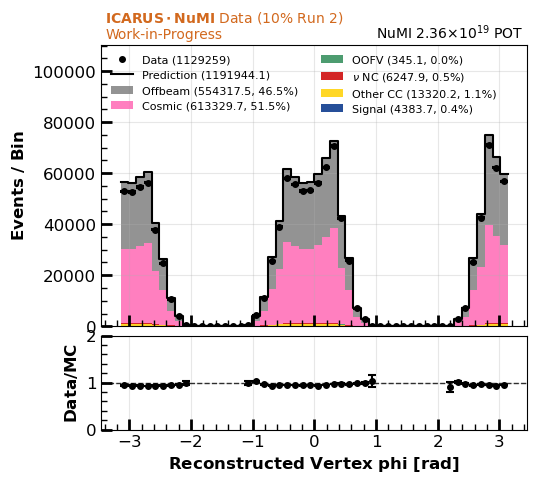

Saved: preselection_vertex_phi


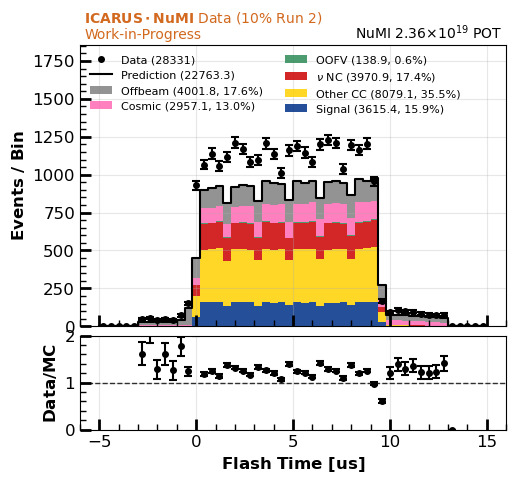

Saved: preselection_flash_time


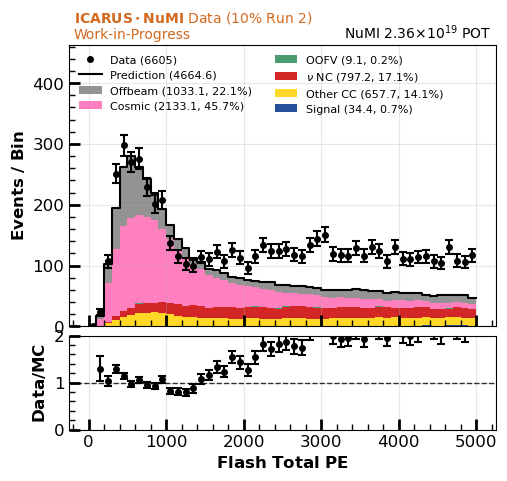

Saved: preselection_flash_total_pe
Done.


In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Configuration
# ============================================================
DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"

OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

ONBEAM_POT  = 2.36124e19
NOMINAL_POT = 7.178e20

CATEGORY_MAP = {
    (0, 1, 3, 4): ("Signal",    "#003087"),
    (6, 7, 8):    ("Other CC",  "#FFD100"),
    (9,):         ("$\\nu$ NC", "#CC0000"),
    (2, 5):       ("OOFV",      "#2E8B57"),
    (10,):        ("Cosmic",    "#FF69B4"),
}

# ============================================================
# Style helpers
# ============================================================
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=12, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', size=4, width=1, direction='in')
    ax.tick_params(axis='x', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.01 * (yrange[1] - yrange[0])
    usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    ax.text(usex, usey,
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + 'Work-in-Progress',
            fontsize=10, color="chocolate",
            verticalalignment="bottom", fontfamily="sans-serif")

def add_pot_label(ax):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.01 * (yrange[1] - yrange[0])
    usex_right = xrange[1] - 0.01 * (xrange[1] - xrange[0])
    ax.text(usex_right, usey,
            f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT",
            fontsize=10, color="black",
            verticalalignment="bottom", horizontalalignment="right",
            fontfamily="sans-serif")

# ============================================================
# Load data
# ============================================================
f = uproot.open(DATA_FILE)

onbeam_lt   = f["events/onbeam/Livetime"].values().sum()
offbeam_lt  = f["events/offbeam/Livetime"].values().sum()

mc_scale      = ONBEAM_POT / NOMINAL_POT
offbeam_scale = onbeam_lt / offbeam_lt

print(f"MC scale:      {mc_scale:.4e}")
print(f"Offbeam scale: {offbeam_scale:.4e}")

mc      = f["events/nominal/preselection"].arrays(library="pd")
onbeam  = f["events/onbeam/preselection"].arrays(library="pd")
offbeam = f["events/offbeam/preselection"].arrays(library="pd")

mc["reco_vertex_phi"]      = np.arctan2(mc["reco_vertex_y"],      mc["reco_vertex_x"])
onbeam["reco_vertex_phi"]  = np.arctan2(onbeam["reco_vertex_y"],  onbeam["reco_vertex_x"])
offbeam["reco_vertex_phi"] = np.arctan2(offbeam["reco_vertex_y"], offbeam["reco_vertex_x"])

def get_category_masks(df):
    masks = {}
    for cats, (label, color) in CATEGORY_MAP.items():
        mask = df["true_category"].isin(cats)
        masks[label] = (mask, color)
    return masks

mc_masks = get_category_masks(mc)

# ============================================================
# Plot function
# ============================================================
def make_plot(variable, xlabel, bins, range_, log=False, output_name=None):
    fig, (ax_main, ax_ratio) = plt.subplots(
        2, 1, figsize=(5.5, 5),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True
    )
    fig.subplots_adjust(hspace=0.05)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width   = bins[1:] - bins[:-1]

    # MC stacked histogram
    mc_total   = np.zeros(len(bins) - 1)
    bottoms    = np.zeros(len(bins) - 1)
    mc_counts  = {}

    for label, (mask, color) in mc_masks.items():
        h, _ = np.histogram(mc.loc[mask, variable].values, bins=bins, range=range_)
        h_scaled = h * mc_scale
        ax_main.bar(bin_centers, h_scaled, width=bin_width, bottom=bottoms,
                    color=color, alpha=0.85)
        bottoms  += h_scaled
        mc_total += h_scaled
        mc_counts[label] = h_scaled.sum()

    # Offbeam
    offbeam_h, _ = np.histogram(offbeam[variable].values, bins=bins, range=range_)
    offbeam_h_scaled = offbeam_h * offbeam_scale
    ax_main.bar(bin_centers, offbeam_h_scaled, width=bin_width, bottom=mc_total,
                color="grey", alpha=0.85)
    mc_counts["Offbeam"] = offbeam_h_scaled.sum()
    prediction = mc_total + offbeam_h_scaled

    # Prediction line
    total_pred_events = prediction.sum()
    ax_main.step(np.append(bins[:-1], bins[-1]),
                 np.append(prediction, prediction[-1]),
                 where='post', color='black', linewidth=1.5)

    # Data
    onbeam_h, _  = np.histogram(onbeam[variable].values, bins=bins, range=range_)
    onbeam_err   = np.sqrt(onbeam_h)
    data_events  = onbeam_h.sum()
    ax_main.errorbar(bin_centers, onbeam_h, yerr=onbeam_err,
                     fmt='o', markersize=4,
                     markerfacecolor="black", markeredgecolor="black",
                     color="black", capsize=3, capthick=1.5, elinewidth=1.5,
                     zorder=5)

    # Build legend with event counts and percentages
    handles = []
    labels_leg = []

    # Data entry
    handles.append(plt.Line2D([0], [0], marker='o', color='black',
                               markerfacecolor='black', markersize=4, linewidth=0))
    labels_leg.append(f"Data ({data_events:.0f})")

    # Prediction entry
    handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5))
    labels_leg.append(f"Prediction ({total_pred_events:.1f})")

    # Offbeam entry
    handles.append(plt.Rectangle((0,0), 1, 1, fc='grey', alpha=0.85))
    labels_leg.append(f"Offbeam ({mc_counts['Offbeam']:.1f}, {mc_counts['Offbeam']/total_pred_events:.1%})")

    # MC category entries (reversed so stack order matches legend)
    for label, (mask, color) in reversed(list(mc_masks.items())):
        cnt = mc_counts[label]
        pct = cnt / total_pred_events
        handles.append(plt.Rectangle((0,0), 1, 1, fc=color, alpha=0.85))
        labels_leg.append(f"{label} ({cnt:.1f}, {pct:.1%})")

    ax_main.legend(handles, labels_leg, fontsize=8, ncol=2,
                   loc='upper left', framealpha=0.0, edgecolor='none')

    ax_main.set_ylabel(r"$\mathbf{Events\ /\ Bin}$", fontsize=12)
    if log:
        ax_main.set_yscale("log")

    # Extend y-axis to make room for legend
    ymax = ax_main.get_ylim()[1]
    ax_main.set_ylim(0, ymax * 1.4)
    ax_main.grid(True, alpha=0.3)
    apply_tick_style(ax_main)
    plt.setp(ax_main.get_xticklabels(), visible=False)

    add_icarus_label(ax_main)
    add_pot_label(ax_main)

    # Ratio panel
    with np.errstate(invalid="ignore", divide="ignore"):
        ratio     = np.where(prediction > 0, onbeam_h / prediction, np.nan)
        ratio_err = np.where(prediction > 0, onbeam_err / prediction, np.nan)

    ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err,
                      fmt='o', markersize=4,
                      markerfacecolor='black', markeredgecolor='black',
                      color='black', capsize=3, capthick=1.5, elinewidth=1.5)
    ax_ratio.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
    ax_ratio.set_ylim(0.0, 2.0)
    ax_ratio.set_ylabel(r"$\mathbf{Data/MC}$", fontsize=12)
    ax_ratio.set_xlabel(r"$\mathbf{" + xlabel.replace(" ", r"\ ") + "}$", fontsize=12)
    ax_ratio.grid(True, alpha=0.3)
    apply_tick_style(ax_ratio)

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    name = output_name or variable
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/{name}.pdf"),   bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{name}.jpeg"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved: {name}")

# ============================================================
# Generate plots
# ============================================================
make_plot("reco_vertex_x",       "Reconstructed Vertex X [cm]",        np.linspace(-400, 400, 51),     (-400, 400),     output_name="preselection_vertex_x")
make_plot("reco_vertex_y",       "Reconstructed Vertex Y [cm]",         np.linspace(-200, 200, 51),     (-200, 200),     output_name="preselection_vertex_y")
make_plot("reco_vertex_z",       "Reconstructed Vertex Z [cm]",         np.linspace(-1000, 1000, 51),   (-1000, 1000),   output_name="preselection_vertex_z")
make_plot("reco_vertex_phi",     "Reconstructed Vertex phi [rad]",      np.linspace(-np.pi, np.pi, 51), (-np.pi, np.pi), output_name="preselection_vertex_phi")
make_plot("reco_flash_time",     "Flash Time [us]",                     np.linspace(-5, 15, 51),        (-5, 15),        output_name="preselection_flash_time")
make_plot("reco_flash_total_pe", "Flash Total PE",                      np.linspace(0, 5000, 51),       (0, 5000),       output_name="preselection_flash_total_pe")

print("Done.")